# Heat Equation

## Generate Data & Fit Basis

#### Imports & Config

In [1]:
# Setup paths and imports
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), '..'))

import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation 
from IPython.display import HTML

import opinf
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam

# Import from core and local modules
from core import summarize_experiment
import config
import step1_generate_data as step1

# ============================================================================
# SET RANDOM SEEDS IMMEDIATELY AFTER IMPORTS
# This ensures identical data generation with 01_gpbayes_opinf.ipynb
# ============================================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
rng_key = jax.random.PRNGKey(RANDOM_SEED)

/home/anthonypoole/miniconda3/envs/prob-rom-inf/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
training_span = (0, 1)
num_samples = 95  # Synced with 01_gpbayes_opinf.ipynb for fair comparison
noiselevel = .105
num_regression_points = 150
numPODmodes = 5
ndraws = 600
time_domain_eval_training = np.linspace(0, training_span[-1], num_regression_points)
normalization = 1e-4
num_initial_conditions = len(config.input_parameters)

### Generate & Visualize Data

In [3]:
# Report experiment setup
summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=normalization,
    ndraws=ndraws,
)

# Generate training data using same sampler as 01_gpbayes_opinf
sampler = step1.TrajectorySampler(
    training_span,
    num_samples,
    noiselevel,
    num_regression_points,
    synced=False,
)
(
    true_states,
    time_domain_sampled,
    snapshots_sampled,
    training_inputs,
) = sampler.multisample(config.input_parameters, plot=False)

(
    true_states_new_initial,
    time_domain_sampled_new_initial,
    snapshots_sampled_new_initial,
    training_inputs_new_initial,
) = sampler.sample(config.test_parameters)

time_domain = config.time_domain

true_states, time_domain_sampled, snapshots_sampled, training_inputs = np.array(true_states), np.array(time_domain_sampled), np.array(snapshots_sampled), np.array(training_inputs)

print(f"Data shapes:")
print(f"  true_states: {true_states.shape}")
print(f"  time_domain_sampled: {time_domain_sampled.shape}")
print(f"  snapshots_sampled: {snapshots_sampled.shape}")


EXPERIMENTAL SCENARIO
Data: 95 uniformly sampled snapshots over 0.00 ≤ t < 1.00 with 10.50% noise
Dimension: retaining 5 POD modes
Training: using 150 regression points
GP regularization: eta = 1.00e-04
Posterior: 600 draws

Data shapes:
  true_states: (5, 500, 500)
  time_domain_sampled: (5, 95)
  snapshots_sampled: (5, 500, 95)


#### Quick description of the outputs
for the true states we have (conditions, x, time)
for the training time domian (conditions, training time)

### Fit Basis

reducing noisy training states to 5 dimensions...done in 0.20 s.
(5, 5, 95) (5, 95) (5, 95) (95,)


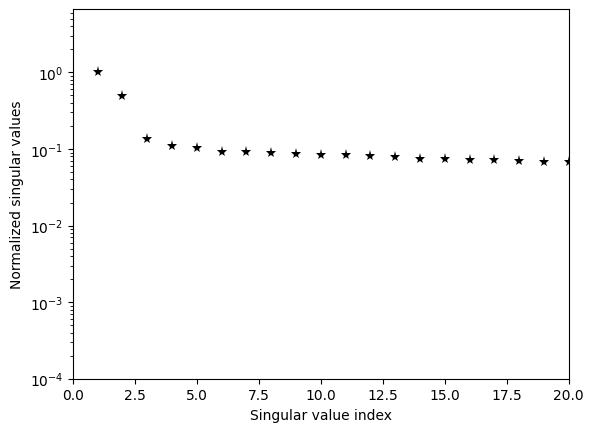

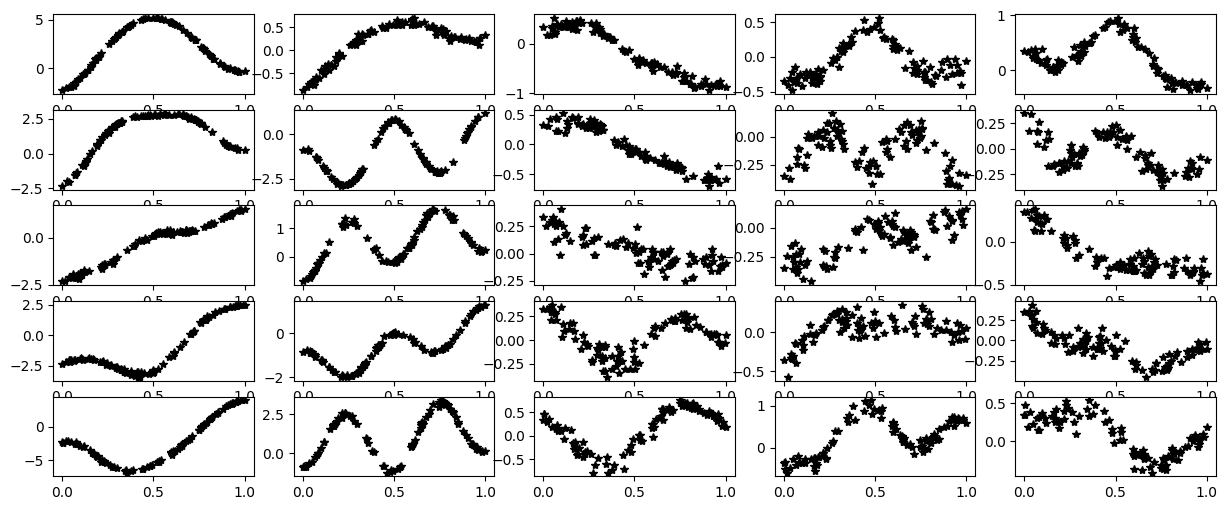

In [4]:
# Start Cell
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    basis.fit(np.hstack(snapshots_sampled))
    ax = basis.plot_svdval_decay()
    ax.set_xlim(right=20)
    ax.set_ylim(bottom=1e-4)
    # utils.save_figure("svdvals.pdf", andopen=openonsave)
    snapshots_compressed = [basis.compress(Q) for Q in snapshots_sampled]
    full_states_compressed = [basis.compress(Q) for Q in true_states]
    snapshots_compressed_new_initial = basis.compress(snapshots_sampled_new_initial)
    full_states_compressed_new_initial = basis.compress(true_states_new_initial)

snapshots_compressed = np.array(snapshots_compressed)
full_states_compressed = np.array(full_states_compressed)
snapshots_compressed_new_initial = np.array(snapshots_compressed_new_initial)
full_states_compressed_new_initial = np.array(full_states_compressed_new_initial)
print(snapshots_compressed.shape, time_domain_sampled.shape, snapshots_compressed_new_initial.shape, time_domain_sampled_new_initial.shape)

fig, ax = plt.subplots(num_initial_conditions, numPODmodes, figsize=(15, 6))
for i in range(num_initial_conditions):
    for j in range(numPODmodes):
        ax[i,j].plot(time_domain_sampled[i], snapshots_compressed[i,j], 'k*', label='True')

## Run Model & Visualize Results

### Bayesian GP

#### Define and Run Model

In [5]:
# Start Cell
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from helpers.bgp_jax import RBFKernel

kernel = RBFKernel()

def model(
        time: jnp.array, 
        qhat: jnp.array,
        normalization=1e-8,  # Very small regularization
    ):
    num_time_steps = time.shape[1]

    time_range = time.max() - time.min()
    
    
    Ls = []
    Vars = []
    noises = []
    
    for i in range(num_initial_conditions):
        # Analyze data scale
        # Get time scale
        time_range = time[i].max() - time[i].min()
        place_holder_ls = []
        place_holder_vars = []
        place_holder_noises = []
        for j in range(numPODmodes): 
            data_std = jnp.std(qhat[i][j])
            lengthscale = numpyro.sample(f"lengthscale{i}{j}", 
                                        dist.LogNormal(jnp.log(time_range/1e1), 1.0))
            place_holder_ls.append(lengthscale)
            
            # Variance based on data variance
            variance = numpyro.sample(f"variance{i}{j}", 
                                    dist.LogNormal(jnp.log(data_std**2), 1.0))
            place_holder_vars.append(variance)
            
            # Small noise since data looks clean
            noise = numpyro.sample(f"noise{i}{j}", 
                                # dist.LogNormal(-8.0, 1.0))  # Very small noise
                                dist.LogNormal(jnp.log(data_std*.1), 1.0))  # Very small noise
            place_holder_noises.append(noise)
            
            # Compute kernel matrix
            K = kernel(time[i].reshape(-1,1), time[i].reshape(-1,1), lengthscale, variance)
            
            # Add tiny regularization for numerical stability
            K_noise = K + (noise + normalization) * jnp.eye(num_time_steps)
            
            # GP prior
            x = numpyro.sample(f"f{i}{j}", dist.MultivariateNormal(jnp.zeros(num_time_steps), K_noise))
            
            # Likelihood
            with numpyro.plate(f"data{i}{j}", num_time_steps):
                numpyro.sample(f"y{i}{j}", dist.Normal(x, jnp.sqrt(noise)), obs=qhat[i][j])

        Ls.append(place_holder_ls)
        Vars.append(place_holder_vars)
        noises.append(place_holder_noises)

Starting SVI optimization...
Iteration 0: loss = 15020.4453
Iteration 100: loss = 14587.7920
Iteration 200: loss = 14178.3809
Iteration 300: loss = 13788.6396
Iteration 400: loss = 13416.2012
Iteration 500: loss = 13059.2227
Iteration 600: loss = 12716.1250
Iteration 700: loss = 12385.5674
Iteration 800: loss = 12066.4062
Iteration 900: loss = 11757.7334
Iteration 1000: loss = 11458.7734
Iteration 1100: loss = 11168.8887
Iteration 1200: loss = 10887.5342
Iteration 1300: loss = 10614.2227
Iteration 1400: loss = 10348.5020
Iteration 1500: loss = 10089.9941
Iteration 1600: loss = 9838.3311
Iteration 1700: loss = 9593.1963
Iteration 1800: loss = 9354.2939
Iteration 1900: loss = 9121.3594
Iteration 2000: loss = 8894.1299
Iteration 2100: loss = 8672.3682
Iteration 2200: loss = 8455.8584
Iteration 2300: loss = 8244.3760
Iteration 2400: loss = 8037.7266
Iteration 2500: loss = 7835.7119
Iteration 2600: loss = 7638.1611
Iteration 2700: loss = 7444.9121
Iteration 2800: loss = 7255.8154
Iteration 

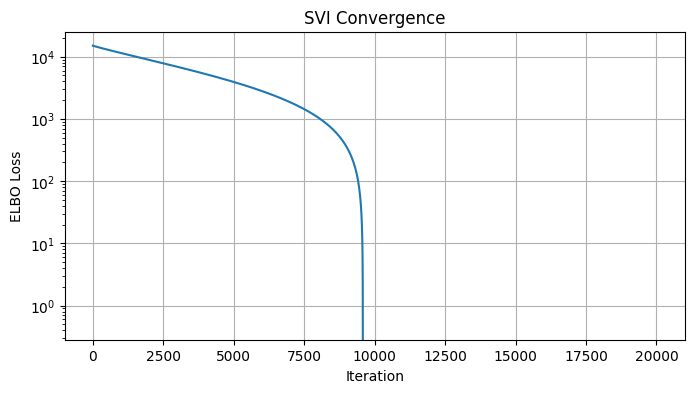

In [6]:
# Create autoguide
# guide = autoguide.AutoNormal(model)
guide = autoguide.AutoDelta(model)

# Setup optimizer - start with higher learning rate and decay
optimizer = Adam(step_size=0.0001)

# Create SVI object
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# Initialize
rng_key = jax.random.PRNGKey(42)
svi_state = svi.init(rng_key,
                     time=time_domain_sampled, 
                     qhat=snapshots_compressed,
                     normalization=normalization
                     )

# Training function
@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time=time_domain_sampled, 
                                  qhat=snapshots_compressed,
                                  normalization=normalization
                                  )
    return svi_state, loss

# Training loop with patience
num_iterations = 20000  # More iterations
losses = []
patience = 1000
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter > patience and i > 5000:
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Rest of your code remains the same...
# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=100)
gp_samples = predictive(rng_key,
                     time=time_domain_sampled, 
                     qhat=snapshots_compressed,
                     normalization=normalization
                     )

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")

# Optional: Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

#### Visualize

#### A quick descriptions of samples samples[i][j] where i is the po

5


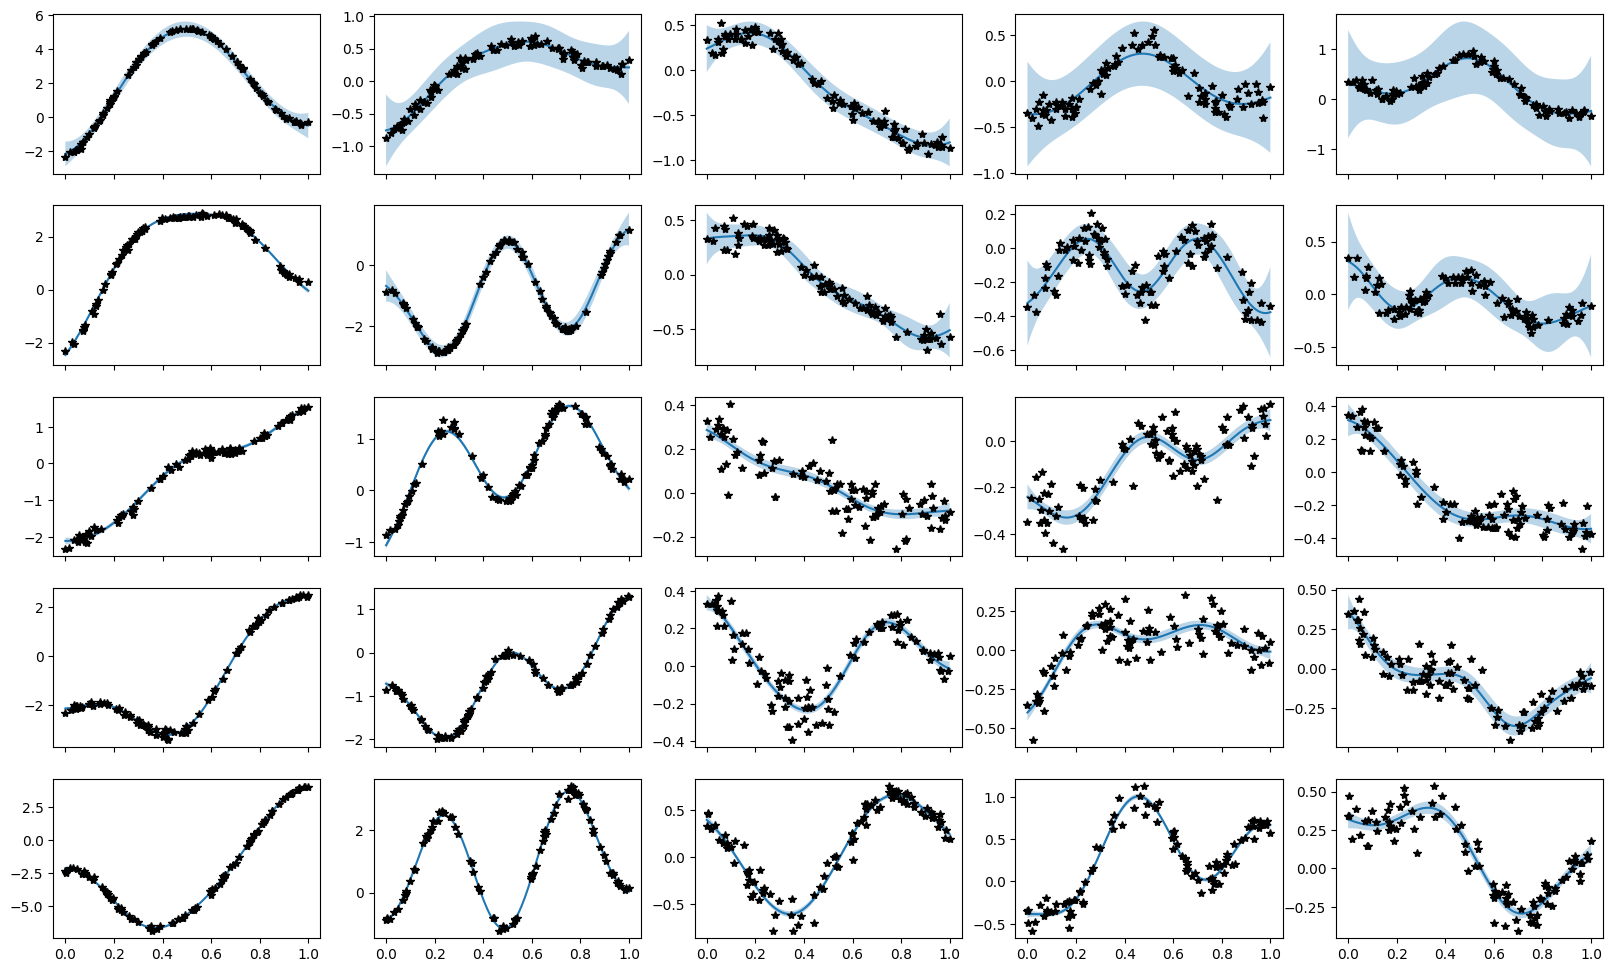

In [7]:
# Plot posterior samples
import heat_plotter
import importlib
importlib.reload(heat_plotter)

plotter = heat_plotter.HeatPlotter(
            numPODmodes=numPODmodes,
            time_domain_training=time_domain_sampled, 
            time_domain_eval_training=time_domain_eval_training,
            time_domain_prediction=time_domain,
            time_domain_eval_prediction=time_domain, # Use full time domain for eval as used in the full order states
            snapshots_training=snapshots_compressed, 
            snapshots_prediction=full_states_compressed,
            )
plotter.gp_plot_state(
    samples = gp_samples,
)

In [8]:
# Start Cell
### Compute mean and std of each thing that we need

Ls_means, Ls_stds, Ls_covs, Vs_means, Vs_stds, Vs_covs, Ns_means, Ns_stds, Ns_covs, Fs_means = [],[],[],[],[],[],[],[],[],[]
for i in range(numPODmodes):
    Ls_means.append(np.array([gp_samples[f'lengthscale{i}{j}'].mean() for j in range(num_initial_conditions)]))
    Ls_stds.append(np.array([gp_samples[f'lengthscale{i}{j}'].std() for j in range(num_initial_conditions)]))
    Ls_covs.append(np.array([jnp.cov(gp_samples[f'lengthscale{i}{j}']) for j in range(num_initial_conditions)]))
    
    Vs_means.append(np.array([gp_samples[f'variance{i}{j}'].mean() for j in range(num_initial_conditions)]))
    Vs_stds.append(np.array([gp_samples[f'variance{i}{j}'].std() for j in range(num_initial_conditions)]))
    Vs_covs.append(np.array([jnp.cov(gp_samples[f'variance{i}{j}']) for j in range(num_initial_conditions)]))
    
    Ns_means.append(np.array([gp_samples[f'noise{i}{j}'].mean() for j in range(num_initial_conditions)]))
    Ns_stds.append(np.array([gp_samples[f'noise{i}{j}'].std() for j in range(num_initial_conditions)]))
    Ns_covs.append(np.array([jnp.cov(gp_samples[f'noise{i}{j}']) for j in range(num_initial_conditions)]))
    
    Fs_means.append(np.array([gp_samples[f'f{i}{j}'].mean(axis=0) for j in range(num_initial_conditions)]))

Ls_means = np.stack(Ls_means)   # → (numPODmodes, n_snapshots)
Ls_stds  = np.stack(Ls_stds)
Ls_covs = np.stack(Ls_covs)
Vs_means = np.stack(Vs_means)
Vs_stds  = np.stack(Vs_stds)
Vs_covs = np.stack(Vs_covs)
Ns_means = np.stack(Ns_means)
Ns_stds  = np.stack(Ns_stds)
Ns_covs = np.stack(Ns_covs)
Fs_means = np.stack(Fs_means) 
Ls_means.shape, Ls_stds.shape, Ls_covs.shape, Vs_means.shape, Vs_stds.shape, Vs_covs.shape, Ns_means.shape, Ns_stds.shape, Ns_covs.shape, Fs_means.shape

((5, 5),
 (5, 5),
 (5, 5),
 (5, 5),
 (5, 5),
 (5, 5),
 (5, 5),
 (5, 5),
 (5, 5),
 (5, 5, 95))

(95, 150)


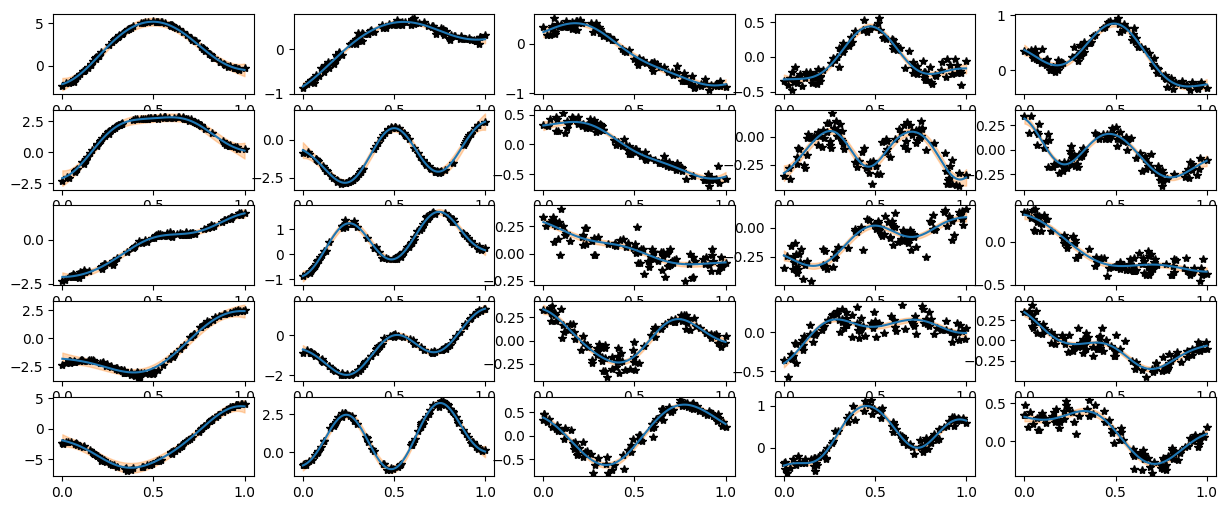

In [9]:
### Plot gp predictions
from helpers.bgp_jax import BayesianGP

eval_points = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)] 
eval_stds = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)] 

gp = BayesianGP()
for i in range(num_initial_conditions):
    for j in range(numPODmodes):
        gp_samples[f'Xi{i}{j}'] = []
        gp_samples[f'XiStd{i}{j}'] = []

        for k in range(num_samples):
            rand_idx = random.randint(0, len(gp_samples['lengthscale00']))
            Ls = gp_samples[f'lengthscale{i}{j}'][rand_idx]
            Vs = gp_samples[f'variance{i}{j}'][rand_idx]
            Ns = gp_samples[f'noise{i}{j}'][rand_idx]

            gp.X_train = time_domain_sampled[i, :][:, None]
            gp.y_train = snapshots_compressed[i, j]
            mean, std, _ = gp.predict_with_hypers(X_test=time_domain_sampled[i, :][:, None], lengthscale=Ls, variance=Vs, noise=Ns)
            mean_test, std_test, _ = gp.predict_with_hypers(X_test=time_domain_eval_training[:, None], lengthscale=Ls, variance=Vs, noise=Ns)
            gp_samples[f'Xi{i}{j}'].append(mean_test)
            gp_samples[f'XiStd{i}{j}'].append(std_test)
        
        gp_samples[f'Xi{i}{j}'] = np.array(gp_samples[f'Xi{i}{j}'])  # Shape (num_samples, num_regression_points)
        gp_samples[f'XiStd{i}{j}'] = np.array(gp_samples[f'XiStd{i}{j}'])  # Shape (num_samples, num_regression_points)
        eval_points[i][j] = gp_samples[f'Xi{i}{j}'].mean(axis=0)
        eval_stds[i][j] = gp_samples[f'XiStd{i}{j}'].mean(axis=0)


print(gp_samples[f'Xi{0}{0}'].shape)

fig, ax = plt.subplots(num_initial_conditions, numPODmodes, figsize=(15, 6))

for i in range(num_initial_conditions):
    for j in range(numPODmodes):
        ax[i,j].plot(time_domain_sampled[i], snapshots_compressed[i,j], 'k*', label='True')
        ax[i,j].plot(time_domain_eval_training, eval_points[i][j], label='Mean prediction')
        ax[i,j].fill_between(time_domain_eval_training, 
                            eval_points[i][j]-2*eval_stds[i][j], 
                            eval_points[i][j]+2*eval_stds[i][j], 
                            color='tab:orange', alpha=0.3, label='Uncertainty (2 std)')

In [10]:
### Dummy rom solve
kernel = RBFKernel()
rom = config.ReducedOrderModel()

ddt = opinf.ddt.NonuniformFiniteDifferencer(time_domain_sampled[0])
_states, ddts, _ = ddt.estimate(states=snapshots_compressed[0,:,:], inputs=training_inputs[0,:, :snapshots_compressed[0,:,:].shape[-1]])
rom.fit(snapshots_compressed[0,:,:], ddts = ddts, inputs=training_inputs[0,:, :snapshots_compressed[0,:,:].shape[-1]])

loaded_operator = rom.operator_matrix

In [11]:
def flatten_time(t: jnp.ndarray) -> jnp.ndarray:
    """Return t with shape (n,) no matter if (n,), (n,1) or (1,n) was given."""
    return jnp.ravel(t)

def rbf_eval(lengthscale: float, variance: float, t: jnp.ndarray, t2: jnp.ndarray) -> jnp.ndarray:
    """Full n×n RBF kernel matrix K_ij = variance * exp(-(t_i-t_j)^2 / (2*ell^2))."""
    t = flatten_time(t)
    t2 = flatten_time(t2)
    diff = t[:, None] - t2[None, :]
    ell2 = lengthscale ** 2
    return variance * jnp.exp(-diff**2 / (2.0 * ell2))

def joint_gp_derivatives(Ls, Vs, time1, time2, snapshots_compressed):
    K_yys = []
    K_zys = []
    K_zzs = []
    for i in range(numPODmodes):
        ell2 = Ls[i]**2
        
        # Standard RBF kernels
        rbf_yy = rbf_eval(Ls[i], Vs[i], time1, time1) 
        rbf_zy = rbf_eval(Ls[i], Vs[i], time2, time1)
        rbf_zz = rbf_eval(Ls[i], Vs[i], time2, time2)

        # K_yy with noise term
        K_yy = rbf_yy + 1e-5 * np.eye(len(time1))  # Fixed: use eye instead of diag
        
        # K_zy: derivative kernel - note the correct difference computation
        diff_zy = time2[:, None] - time1[None, :]  # (250, 150)
        K_zy = -(diff_zy / ell2) * rbf_zy  # (250, 150)
        
        # K_zz: second derivative kernel
        diff_zz = time2[:, None] - time2[None, :]  # (250, 250)
        K_zz = ((1 - (diff_zz**2 / ell2)) / ell2) * rbf_zz  # (250, 250)
        
        K_yys.append(K_yy)
        K_zys.append(K_zy)
        K_zzs.append(K_zz)

    # Now the prediction should work
    mu_z = []
    cov_z = []
    for i in range(numPODmodes):
        w = jnp.linalg.solve(K_yys[i], snapshots_compressed[i])  # w shape: (150,)
        mu_zi = K_zys[i] @ w  # (250, 150) @ (150,) = (250,)
        mu_z.append(mu_zi)

        cov_zi = K_zzs[i] - K_zys[i] @ jnp.linalg.solve(K_yys[i], K_zys[i].T)
        cov_z.append(cov_zi)

    return jnp.array(mu_z), jnp.array(cov_z)  # Shape should be (6, 250)

In [12]:
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from helpers.bgp_jax import RBFKernel, get_c_phi, get_dash_c_phi, get_c_phi_dash, get_c_phi_double_dash 

kernel = RBFKernel()


def model(time, normalization=1e-6):
    num_time_steps = time.shape[0]
    gamma = 8e-1 #4e2, 1e0
    # gamma = 1e-1 #4e2, 1e0

    min_std = 2e1   # lower bound
    factor  = 0.5   # scaling factor

    # O = numpyro.sample(
    #     "O",
    #     dist.Normal(
    #         loc=loaded_operator,
    #         scale=jnp.maximum(min_std, factor * jnp.abs(loaded_operator))
    #     )
    # )

    O = numpyro.sample(
        "O",
        dist.Normal(
            loc=jnp.zeros_like(loaded_operator),
            scale=gamma * jnp.ones_like(loaded_operator)
        )
    )

    Xs = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)]
    Ls = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)]
    Vars = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)]
    noises = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)]
    Kyys = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)]
    
    for i in range(num_initial_conditions):
        for j in range(numPODmodes):
            lengthscale = Ls_means[i][j]
            Ls[i][j].append(lengthscale)

            variance = Vs_means[i][j]
            Vars[i][j].append(variance)

            noise = Ns_means[i][j]
            noises[i][j].append(noise)

            Kyy = get_c_phi(lengthscale, variance, time, normalization)
            Kyys[i][j].append(Kyy)

            Xs[i][j].append(
                numpyro.sample(
                    f"X{i}{j}",
                    dist.MultivariateNormal(loc=eval_points[i][j], covariance_matrix=jnp.diag(eval_stds[i][j])+normalization*jnp.eye(eval_stds[i][j].shape[0])),
                )
            )
        
        Ls[i] = jnp.array(Ls[i]).squeeze()
        Vars[i] = jnp.array(Vars[i]).squeeze()
        noises[i] = jnp.array(noises[i]).squeeze()
        Kyys[i] = jnp.array(Kyys[i]).squeeze()
        Xs[i] = jnp.array(Xs[i]).squeeze()
    
    Ls = jnp.array(Ls)
    Vars = jnp.array(Vars)
    noises = jnp.array(noises)
    Kyys = jnp.array(Kyys)
    Xs = jnp.array(Xs)
        
    for i in range(num_initial_conditions):
        f_Xi_ohat = rom._assemble_data_matrix(Xs[i], inputs=training_inputs[i]) @ O.T

        mu_z, cov_z = joint_gp_derivatives(Ls[i], Vars[i], time_domain_sampled[i], time, snapshots_compressed=snapshots_compressed[i])
    
        for j in range(numPODmodes):
            mu_zi = mu_z[j]
            cov_zi = cov_z[j]
            constraint_cov = cov_zi + gamma * jnp.eye(num_time_steps)

            numpyro.sample(
                f'ode_constraint{i}{j}',
                dist.MultivariateNormal(mu_zi, constraint_cov),
                obs=f_Xi_ohat.T[j]
            )

Starting SVI optimization...
Iteration 0: loss = 156488.3125
Iteration 100: loss = 140459.7188
Iteration 200: loss = 129007.6094
Iteration 300: loss = 119576.5234
Iteration 400: loss = 111007.9609
Iteration 500: loss = 102770.8125
Iteration 600: loss = 94614.0391
Iteration 700: loss = 86457.0312
Iteration 800: loss = 78378.7734
Iteration 900: loss = 70565.4922
Iteration 1000: loss = 63238.9258
Iteration 1100: loss = 56597.5078
Iteration 1200: loss = 50767.8398
Iteration 1300: loss = 45780.6250
Iteration 1400: loss = 41583.2188
Iteration 1500: loss = 38074.7344
Iteration 1600: loss = 35139.8086
Iteration 1700: loss = 32669.2109
Iteration 1800: loss = 30567.9668
Iteration 1900: loss = 28757.2480
Iteration 2000: loss = 27174.2051
Iteration 2100: loss = 25770.5234
Iteration 2200: loss = 24510.1367
Iteration 2300: loss = 23366.4258
Iteration 2400: loss = 22319.6348
Iteration 2500: loss = 21354.9023
Iteration 2600: loss = 20460.9121
Iteration 2700: loss = 19628.8125
Iteration 2800: loss = 18

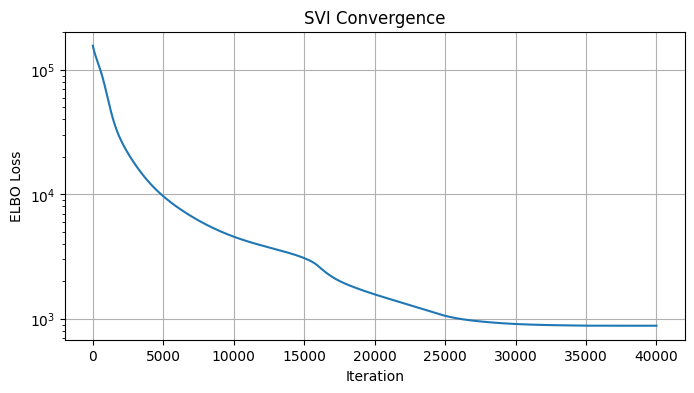

In [13]:
guide = autoguide.AutoDelta(model)

normalization = 1e-6

optimizer = Adam(step_size=0.0005)
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

svi_state = svi.init(rng_key,
                     time=time_domain_eval_training, 
                     normalization=normalization
                     )

# Training function
@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time=time_domain_eval_training, 
                                  normalization=normalization
                                  )
    return svi_state, loss

num_iterations = 40000
losses = []
patience = 500
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if (patience_counter > patience and i > 5000):
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=1000)
gm_samples = predictive(rng_key,
                     time=time_domain_eval_training, 
                     normalization=normalization
                     )

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

In [14]:
# Get initial values from your SVI/guide samples
Omean = gm_samples['O'].mean(axis=0)
Ostd = gm_samples['O'].std(axis=0)
num_chains = 4
numpyro.set_host_device_count(num_chains)

def reparameterized_model(time, normalization=1e-6, gamma=1e1):
    num_time_steps = time.shape[0]

    min_std = 2e1   # lower bound
    factor  = 0.5   # scaling factor

    # O = numpyro.sample(
    #     "O",
    #     dist.Normal(
    #         loc=loaded_operator,
    #         scale=jnp.maximum(min_std, factor * jnp.abs(loaded_operator))
    #     )
    # )
    min_relative_std = .15 # 1
    min_absolute_std = .8 # 2.
    O_uncertainty = jnp.maximum(Ostd, jnp.maximum(min_relative_std * jnp.abs(Omean), min_absolute_std))
    
    # Sample standardized O (zero mean, unit variance)
    O_standardized = numpyro.sample('O_standardized', 
                                    dist.Normal(jnp.zeros_like(Omean), 
                                               jnp.ones_like(Omean)))
    
    # Deterministically transform to actual O
    # This makes O = Omean + O_uncertainty * O_standardized
    O = numpyro.deterministic('O', Omean + O_uncertainty * O_standardized)
    

    Xs = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)]
    Ls = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)]
    Vars = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)]
    noises = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)]
    Kyys = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)]
    
    for i in range(num_initial_conditions):
        for j in range(numPODmodes):
            lengthscale = Ls_means[i][j]
            Ls[i][j].append(lengthscale)

            variance = Vs_means[i][j]
            Vars[i][j].append(variance)

            noise = Ns_means[i][j]
            noises[i][j].append(noise)

            Kyy = get_c_phi(lengthscale, variance, time, normalization)
            Kyys[i][j].append(Kyy)

            Xs[i][j].append(
                numpyro.sample(
                    f"X{i}{j}",
                    dist.MultivariateNormal(loc=eval_points[i][j], covariance_matrix=jnp.diag(eval_stds[i][j])+normalization*jnp.eye(eval_stds[i][j].shape[0])),
                )
            )
        
        Ls[i] = jnp.array(Ls[i]).squeeze()
        Vars[i] = jnp.array(Vars[i]).squeeze()
        noises[i] = jnp.array(noises[i]).squeeze()
        Kyys[i] = jnp.array(Kyys[i]).squeeze()
        Xs[i] = jnp.array(Xs[i]).squeeze()
    
    Ls = jnp.array(Ls)
    Vars = jnp.array(Vars)
    noises = jnp.array(noises)
    Kyys = jnp.array(Kyys)
    Xs = jnp.array(Xs)
        
    for i in range(num_initial_conditions):
        f_Xi_ohat = rom._assemble_data_matrix(Xs[i], inputs=training_inputs[i]) @ O.T

        mu_z, cov_z = joint_gp_derivatives(Ls[i], Vars[i], time_domain_sampled[i], time, snapshots_compressed=snapshots_compressed[i])
    
        for j in range(numPODmodes):
            mu_zi = mu_z[j]
            cov_zi = cov_z[j]
            constraint_cov = cov_zi + gamma * jnp.eye(num_time_steps)

            numpyro.sample(
                f'ode_constraint{i}{j}',
                dist.MultivariateNormal(mu_zi, constraint_cov),
                obs=f_Xi_ohat.T[j]
            )

In [15]:
from numpyro.infer import MCMC, NUTS, init_to_value
from numpyro.diagnostics import summary
import jax.numpy as jnp
import numpyro.distributions as dist
import numpyro

# === INITIALIZE WITH GOOD VALUES ===
init_values_standardized = {
    'O_standardized': jnp.zeros_like(Omean),  # Start at the mean
}

dense_mass_blocks = [
    ("O_standardized",),  # O parameters are correlated within themselves
    tuple([f"X{i}_standardized" for i in range(numPODmodes)])  # X parameters likely correlated
]

# === RUN MCMC WITH IMPROVED SETTINGS ===
print("Running MCMC with reparameterized model...")
nuts_kernel = NUTS(
    reparameterized_model,
    init_strategy=init_to_value(values=init_values_standardized),
    # dense_mass=dense_mass_blocks,  # Use structured mass matrix
    # max_tree_depth=12,  # Increase from default 10
    target_accept_prob=0.9,  # Increase for better exploration in difficult geometries
)

mcmc = MCMC(
    nuts_kernel,
    num_warmup=250,  # Increase warm-up for better adaptation
    num_samples=500,
    num_chains=num_chains,
    chain_method='parallel',
    progress_bar=True,
)

# Run with moderate gamma first
mcmc.run(
    rng_key,
    time=time_domain_eval_training,
    gamma=.5e1,  # You can adjust this
    normalization=normalization,
)

Running MCMC with reparameterized model...


sample: 100%|██████████| 750/750 [02:41<00:00,  4.65it/s, 63 steps of size 1.04e-01. acc. prob=0.92]  


In [16]:
# === CHECK DIAGNOSTICS ===
def print_diagnostics(mcmc):
    """Print detailed diagnostics for each parameter"""
    samples = mcmc.get_samples(group_by_chain=True)
    summary_dict = summary(samples)
    
    print("\n" + "="*60)
    print("MCMC Diagnostics Summary")
    print("="*60)
    
    # Separate standardized and deterministic variables
    standardized_params = []
    deterministic_params = []
    constraint_params = []
    
    for param in summary_dict.keys():
        if '_standardized' in param:
            standardized_params.append(param)
        elif 'ode_constraint' in param:
            constraint_params.append(param)
        else:
            deterministic_params.append(param)
    
    # Print standardized parameters (these are what we actually sample)
    if standardized_params:
        print("\n📊 Standardized Parameters (key for convergence):")
        print("-" * 50)
        for param in sorted(standardized_params):
            stats = summary_dict[param]
            max_rhat = jnp.max(stats["r_hat"])
            min_ess = jnp.min(stats["n_eff"])
            
            if max_rhat > 1.01:
                status = "⚠️ "
            else:
                status = "✅"
            
            print(f"{status} {param:30s} r_hat={max_rhat:.4f}, min_ESS={min_ess:.0f}")
    
    # Print deterministic transformations
    if deterministic_params:
        print("\n📈 Transformed Parameters:")
        print("-" * 50)
        for param in sorted(deterministic_params):
            stats = summary_dict[param]
            max_rhat = jnp.max(stats["r_hat"])
            print(f"   {param:30s} r_hat={max_rhat:.4f}")
    
    # Check for problems
    problem_params = [p for p, s in summary_dict.items() 
                     if jnp.max(s["r_hat"]) > 1.01 and '_standardized' in p]
    
    if problem_params:
        print(f"\n⚠️  Warning: {len(problem_params)} parameters have r_hat > 1.01")
        print("Consider:")
        print("  1. Increasing num_warmup and num_samples")
        print("  2. Adjusting gamma (try values between 1e-2 and 1e-1)")
        print("  3. Checking if normalization needs adjustment")
    else:
        print("\n✅ All parameters have converged well (r_hat ≤ 1.01)")
    
    return summary_dict

# Print diagnostics
diagnostics = print_diagnostics(mcmc)

# Get the final samples
samples = mcmc.get_samples()
print(f"\nSampling complete. Retrieved {len(samples['O'])} samples.")


MCMC Diagnostics Summary

📊 Standardized Parameters (key for convergence):
--------------------------------------------------
✅ O_standardized                 r_hat=1.0049, min_ESS=1230

📈 Transformed Parameters:
--------------------------------------------------
   O                              r_hat=1.0049
   X00                            r_hat=1.0013
   X01                            r_hat=1.0017
   X02                            r_hat=1.0026
   X03                            r_hat=1.0026
   X04                            r_hat=1.0014
   X10                            r_hat=1.0012
   X11                            r_hat=1.0020
   X12                            r_hat=1.0017
   X13                            r_hat=1.0022
   X14                            r_hat=1.0019
   X20                            r_hat=1.0019
   X21                            r_hat=1.0013
   X22                            r_hat=1.0010
   X23                            r_hat=1.0011
   X24                        

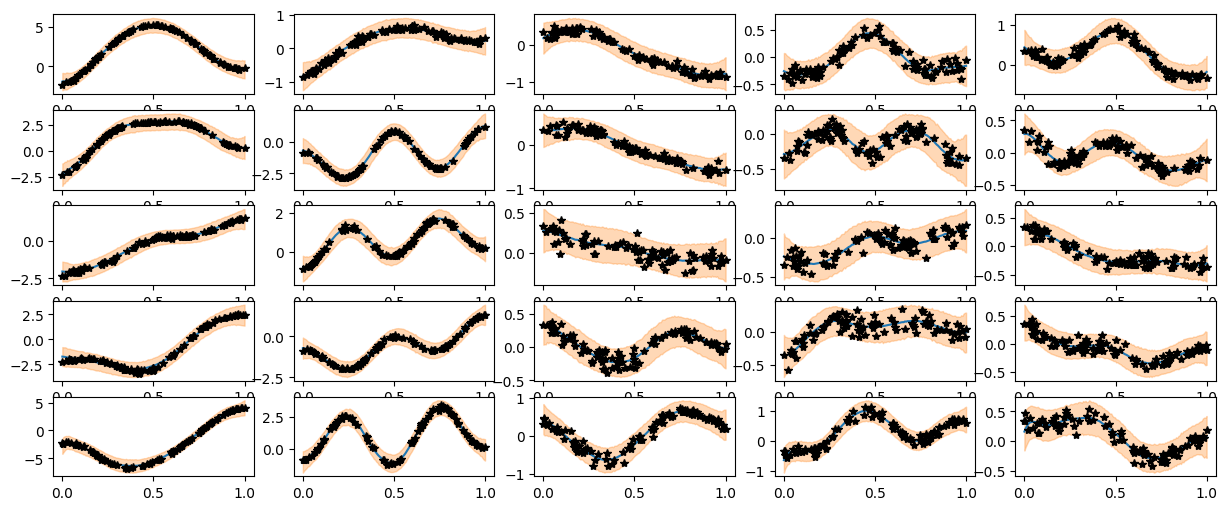

In [17]:
### Sanity check of the latent states

fig, ax = plt.subplots(num_initial_conditions, numPODmodes, figsize=(15, 6))

Xs_means = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)]
Xs_stds = [[[] for j in range(numPODmodes)] for i in range(num_initial_conditions)]

for i in range(num_initial_conditions):
    for j in range(numPODmodes):
        Xs_means[i][j] = np.array(samples[f'X{i}{j}']).mean(axis=0)
        Xs_stds[i][j] = np.array(samples[f'X{i}{j}']).std(axis=0)

        ax[i,j].plot(time_domain_eval_training, Xs_means[i][j], label='Mean prediction')
        ax[i,j].fill_between(time_domain_eval_training, 
                            Xs_means[i][j]-2*Xs_stds[i][j], 
                            Xs_means[i][j]+2*Xs_stds[i][j], 
                            color='tab:orange', alpha=0.3, label='Uncertainty (2 std)')
        ax[i,j].plot(time_domain_sampled[i], snapshots_compressed[i,j], 'k*', label='True')


In [18]:
Os = []
Xs = [[] for i in range(num_initial_conditions)]
rom_solves = [[] for i in range(num_initial_conditions)]

# TODO: Add support for test initial condition
for i in range(num_initial_conditions):
    for j in range(ndraws):
        O = samples['O'][j]
        if i == 0:
            Os.append(O)
        rom._extract_operators(np.array(O))
        Xs[i].append(np.array([samples[f'X{i}{k}'][j] for k in range(numPODmodes)]))
        rom.predict(state0=snapshots_compressed[i, :, 0], t=time_domain_eval_training, input_func=config.input_func_factory(config.input_parameters[i]))

        if rom.predict_result_.y.shape[1] < time_domain_eval_training.size:
            print("Bad solve, skipping", rom.predict_result_.y.shape)
            continue
        rom_solves[i].append(rom.predict_result_.y)

rom_solves_new_initial = []
Os = np.array(Os)

for i in range(ndraws):
    O = samples['O'][i]
    rom._extract_operators(np.array(O))
    rom.predict(state0=snapshots_compressed_new_initial[:, 0], t=time_domain_eval_training, input_func=config.input_func_factory(config.test_parameters))
    if rom.predict_result_.y.shape[1] < time_domain_eval_training.size:
        print("Bad solve, skipping", rom.predict_result_.y.shape)
        continue

    rom_solves_new_initial.append(rom.predict_result_.y)

Bad solve, skipping (5, 144)
Bad solve, skipping (5, 139)
Bad solve, skipping (5, 142)
Bad solve, skipping (5, 134)
Bad solve, skipping (5, 141)
Bad solve, skipping (5, 118)
Bad solve, skipping (5, 128)
Bad solve, skipping (5, 144)
Bad solve, skipping (5, 130)
Bad solve, skipping (5, 146)


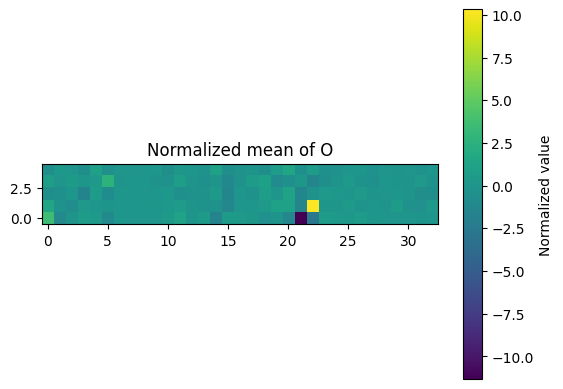

In [19]:
O_mean = Os.mean(axis=0)

# Normalize to [0, 1]

plt.imshow(O_mean, cmap="viridis", origin="lower")
plt.colorbar(label="Normalized value")  # colorbar instead of legend
plt.title("Normalized mean of O")
plt.show()

Bad solve, skipping (5, 393)
Bad solve, skipping (5, 431)
Bad solve, skipping (5, 405)
Bad solve, skipping (5, 442)
Bad solve, skipping (5, 446)
Bad solve, skipping (5, 392)
Bad solve, skipping (5, 495)
Bad solve, skipping (5, 465)
Bad solve, skipping (5, 399)
Bad solve, skipping (5, 384)
Bad solve, skipping (5, 441)
Bad solve, skipping (5, 395)
Bad solve, skipping (5, 409)
Bad solve, skipping (5, 347)
Bad solve, skipping (5, 383)
Bad solve, skipping (5, 354)
Bad solve, skipping (5, 377)
Bad solve, skipping (5, 422)
Bad solve, skipping (5, 422)
Bad solve, skipping (5, 400)
Bad solve, skipping (5, 446)
Bad solve, skipping (5, 344)
Bad solve, skipping (5, 456)
Bad solve, skipping (5, 466)
Bad solve, skipping (5, 412)
Bad solve, skipping (5, 482)
Bad solve, skipping (5, 366)
Bad solve, skipping (5, 488)
Bad solve, skipping (5, 333)
Bad solve, skipping (5, 474)
Bad solve, skipping (5, 451)
Bad solve, skipping (5, 380)
Bad solve, skipping (5, 433)
Bad solve, skipping (5, 393)
Bad solve, ski

<Figure size 640x480 with 0 Axes>

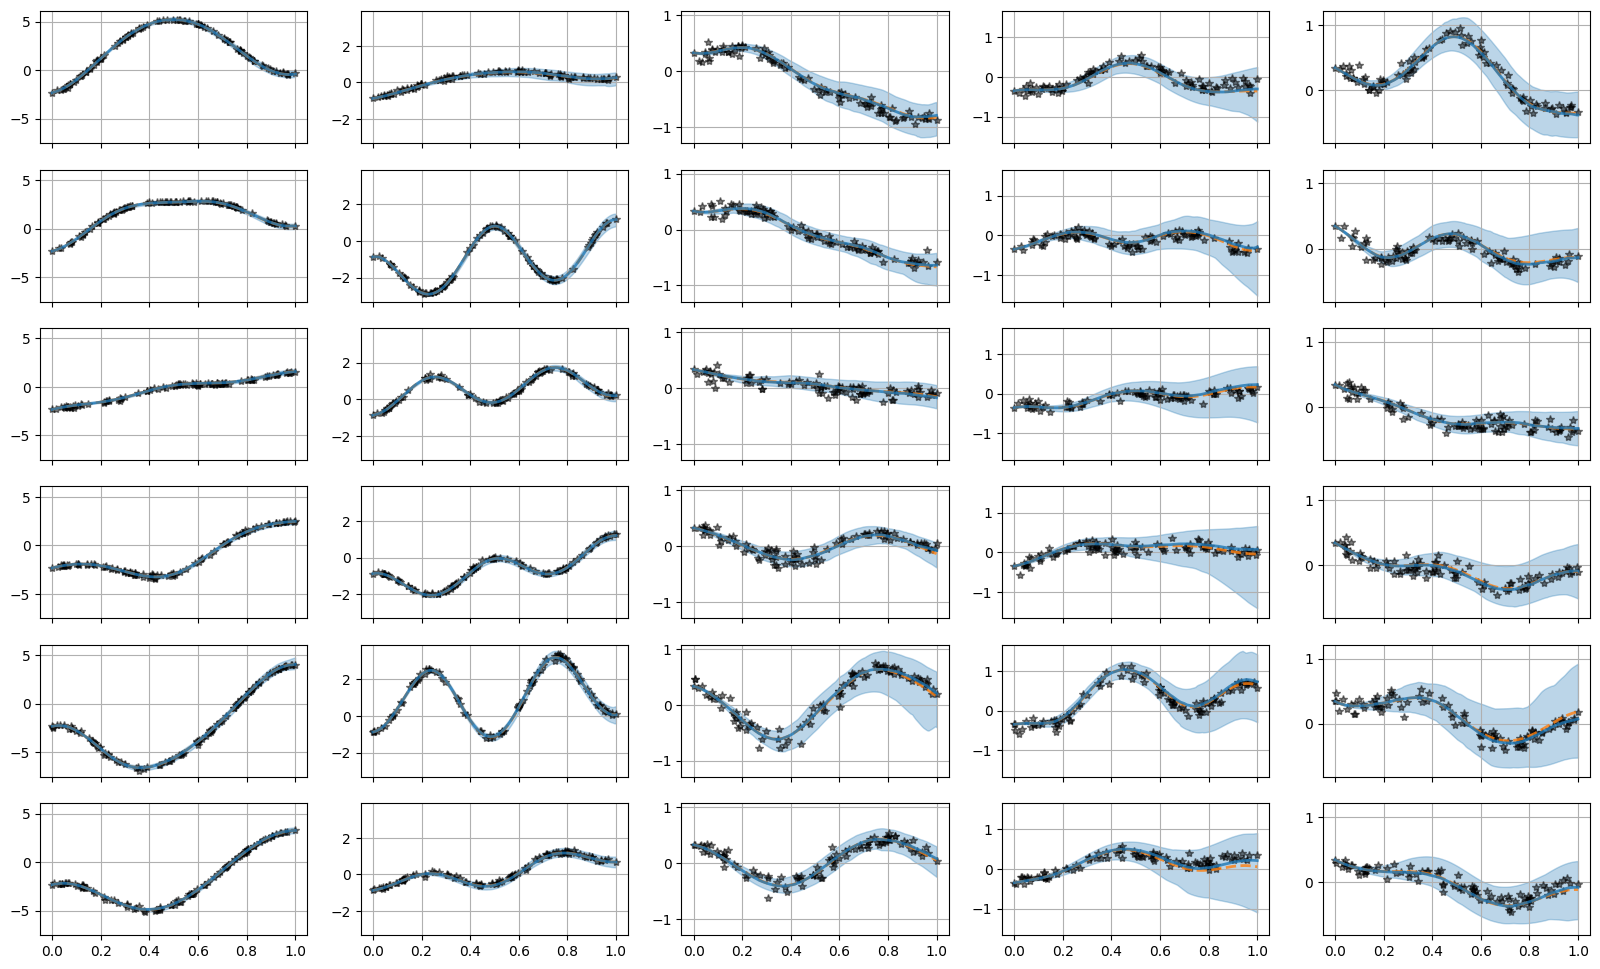

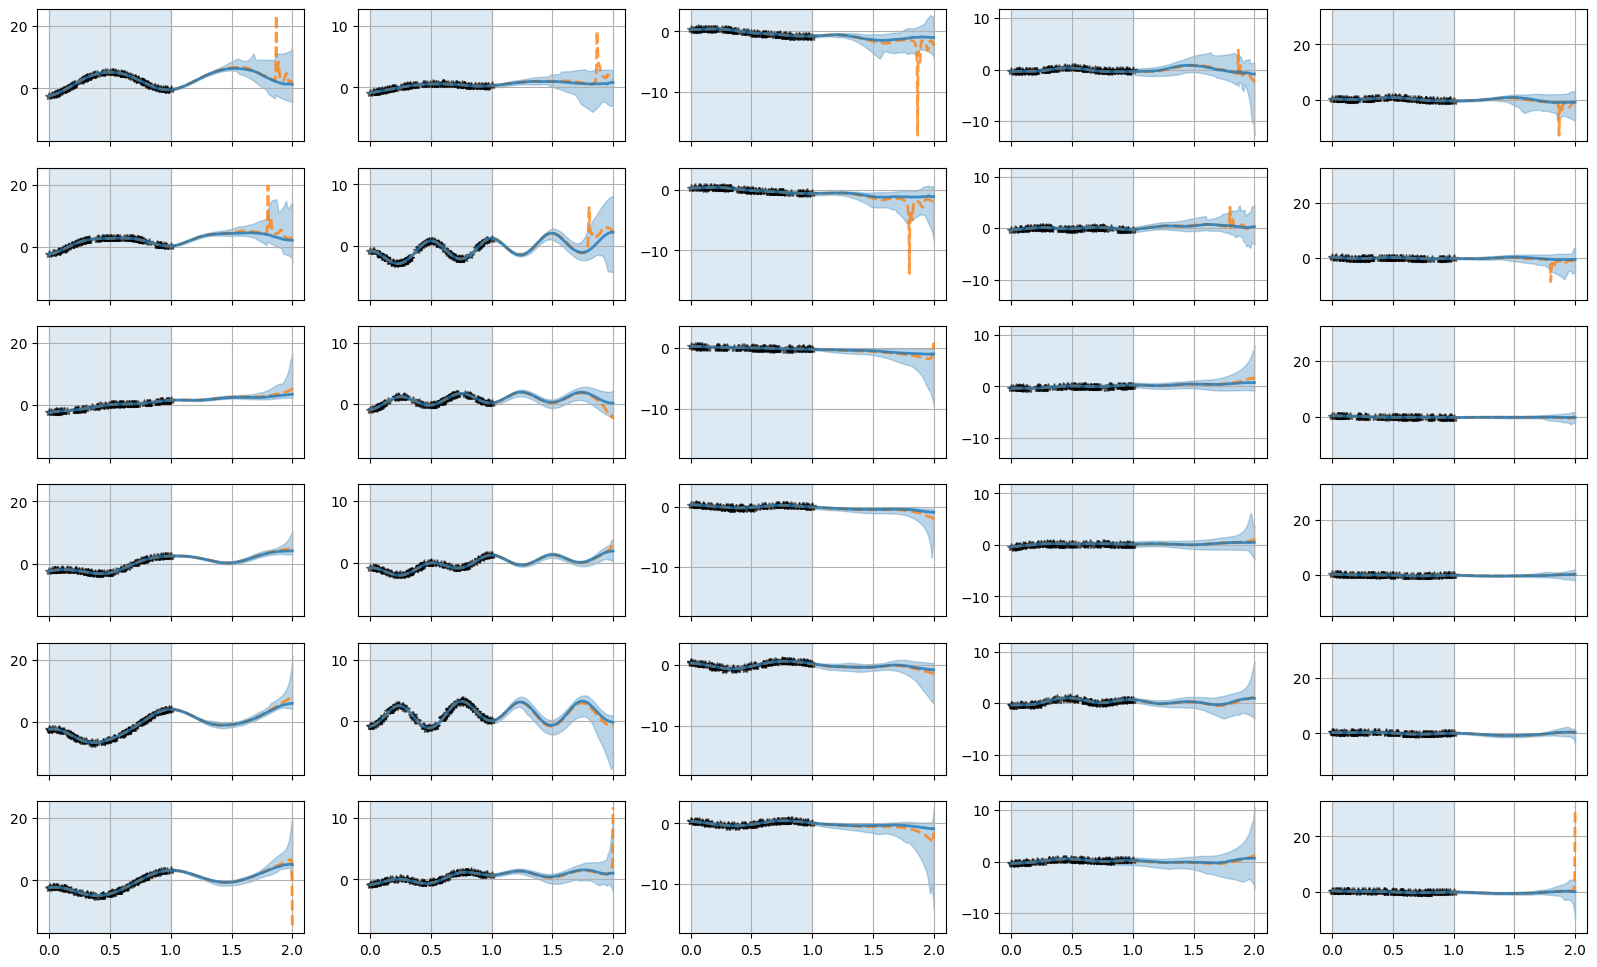

<Figure size 2000x1200 with 0 Axes>

In [20]:
# Plot posterior samples
import heat_plotter
import importlib
importlib.reload(heat_plotter)

plotter = heat_plotter.HeatPlotter(
            numPODmodes=numPODmodes,
            time_domain_training=time_domain_sampled, 
            time_domain_eval_training=time_domain_eval_training,
            time_domain_prediction=time_domain,
            time_domain_eval_prediction=time_domain, # Use full time domain for eval as used in the full order states
            snapshots_training=snapshots_compressed, 
            snapshots_prediction=full_states_compressed,
            )

plotter.operator_plot(
    # TODO: fix this cheating
    q0 = None,
    operator_samples = Os,
    latent_state_samples = Xs,
    snapshots_training_prediction_parameters = snapshots_compressed_new_initial,
    time_domain_training_prediction_parameters = time_domain_sampled_new_initial,
    snapshots_prediction_new_initial = full_states_compressed_new_initial,
    rom = rom,
    input_func = config.input_func_factory,
    input_parameters_training = config.input_parameters,
    input_parameters_prediction = config.test_parameters,
    figsize = (20, 12),
    max_num_samples = 100,
    plot_samples = False
)